# Probes Articles exploration Dataset

The following notebook analyses the data produced from Probes pilot study
- diseases found within the same sentence as probes-target entitites.
- Exploration of articles diseases extra annotation for diseases mentioned in the whole article.
- Checking the mentioning of probes controls within the articles.
- Checking the mentioning of control keywords within the articles.
- Checking the mentioning of a dosage/activty units keywords, to capture activity/dosage values.

##### Settings and modules

In [34]:
#Importing general modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import itertools
import collections
import pandas as pd
import plotly.graph_objects as go

#Importing OnToma module for disease ontology mapping according to OpenTargets
from ontoma import OnToma
cache_dir = os.path.expanduser("~/.ontoma_cache")
os.makedirs(cache_dir, exist_ok=True)
otmap = OnToma(cache_dir=cache_dir)

#Importing own modules
from databases import ChemblDB

#Setting up display options
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

##### Connecting to ChEMBL database dump

In [ ]:
#Connecting to chembl DB
chemblpath = 'chembl_35/chembl_35_sqlite/chembl_35.db' #replace your own path to chembl.db sqlite dump
chembl = ChemblDB(chemblpath)


#### Chemical probes subset
Main chemical probes subset containing the chemical probes from Probes & Drugs HQ subset (excluding chemical probes from chemicalprobes.org) retrieved on July 2022. It includes the original source set, the chemical probe's name, chemical probe's inchikey, probe's target (uniprot and gene), negative control (if available), references, among other data.

In [36]:
#Loading subset
mainset = pd.read_csv('data/mainset.csv', sep='\t')
probes_inchi = dict(zip(mainset.PROBE, mainset.INCHI))

In [37]:
#Probes and targets synonyms dictionary
probes_syn = mainset[['PROBE','SYNOMS']].drop_duplicates()
targets_syn = mainset[['UNIPROT','SYNOMS_TARGET']]
display(probes_syn.head(15))
display(targets_syn.head(3))

,PROBE,SYNOMS
0,Benzimidazolone 8,"compound 34 [PMID: 25974391, Benzimidazolone 8"
4,dTRIM24,"dTRIM24, cpd 2, canSAR3314073"
9,PFI-4,"PFI 4, PFI4, PFI-4"
23,NI-57,"NI-57, NI 57, GTPL8573, canSAR1874277"
45,GSK6853,"GSK 6853, GSK6853, GSK-6853"
53,OF-1,"OF-1, OF1, OF 1"
67,LP99,"GTPL8572, LP99, canSAR661124, LP 99, LP99 , AK475255, LP-99"
89,I-BRD9,"I-BRD9, I-BRD9 (GSK602), GSK602, canSAR541825, CS-5587"
111,BI-9564,"canSAR1780473, None, BI9564, BI 9564, BI-9564"
132,TP-472,"TP 472, TP-472, TP-472"


,UNIPROT,SYNOMS_TARGET
0,O15164,"2.3.2.27, E3 ubiquitin-protein ligase TRIM24, RING finger protein 82, RING-type E3 ubiquitin transferase TIF1-alpha, RNF82, TIF1, TIF1-alpha, TIF1A, TRIM24, Transcription intermediary factor 1-alpha, Tripartite motif-containing protein 24"
1,O15164,"2.3.2.27, E3 ubiquitin-protein ligase TRIM24, RING finger protein 82, RING-type E3 ubiquitin transferase TIF1-alpha, RNF82, TIF1, TIF1-alpha, TIF1A, TRIM24, Transcription intermediary factor 1-alpha, Tripartite motif-containing protein 24"
2,O15164,"2.3.2.27, E3 ubiquitin-protein ligase TRIM24, RING finger protein 82, RING-type E3 ubiquitin transferase TIF1-alpha, RNF82, TIF1, TIF1-alpha, TIF1A, TRIM24, Transcription intermediary factor 1-alpha, Tripartite motif-containing protein 24"


#### Dataset with chemical probes articles found in the pilot study

After executing the tag-based search on ErupoPMC tagged entities file, the report contains all articles having a tagging match of a chemical probe-target cooccurrences within sentences.

In [38]:
#Results after search in json files
dataset = pd.read_csv('data/pmc_probes_match_ann.csv', sep='\t', dtype=str).drop_duplicates().replace('[]', None).replace('None', None)
dataset = dataset.fillna(value=np.nan)
print("All tagging matches: {}".format(len(dataset))) #all matches
print("Unique articles: {}".format(dataset.PMID.nunique())) #unique articles
print("Unique sentences: {}".format(dataset.TEXT.nunique())) #unique sentences
print("Unique target-probe pairs: {}".format(dataset.groupby(['TAR', 'COMP']).ngroups)) #unique target-probe pair
print("Unique labels pairs: {}".format(dataset.groupby(['LABEL1', 'LABEL2']).ngroups)) #unique labels pairs

All tagging matches: 5978
Unique articles: 1470
Unique sentences: 4008
Unique target-probe pairs: 110
Unique labels pairs: 200


#### Example of an article having a tag match in the section "Other" 

In this particular case, the article has a tag matching of the probe-target entitites within the references section. Therefore, the sentence is not exactly part of this article but rather coming from other article that is cited in here (secondary data). In such cases, the tagging system leads to redundant data.

In [39]:
#Example of one article in the section "Other"
display(dataset[(dataset.SECTION == 'Other') & (dataset.PMID == '31478830')].drop_duplicates().drop_duplicates(subset=['PMID']).head(10))

,PMID,SECTION,TAR,GENE,COMP,PROBE,CONTR,LABEL1,LABEL2,START1,END1,START2,END2,TEXT,DISEASES,DISEASE_FOUND,DOSAGE,CONTROL,PMCID,ASSAY
4125,31478830,Other,Q05397,PTK2,30737,DEFACTINIB,PF-00911705,FAK,VS-6063,296,299,310,317,Lin Lin HM HM Lee Lee BY BY Castillo Castillo L L Spielman Spielman C C Grogan Grogan J J Yeung Yeung NK NK Kench Kench JG JG Stricker Stricker PD PD Haynes Haynes AM AM Centenera Centenera MM MM Butler Butler LM LM Shreeve Shreeve SM SM Horvath Horvath LG LG Daly Daly RJ RJ 2018 2018 Effect of FAK inhibitor VS-6063 (defactinib) on docetaxel efficacy in prostate Cancer Effect of FAK inhibitor VS-6063 (defactinib) on docetaxel efficacy in prostate Cancer The Prostate The Prostate 78 78 308 308 317 317 10.1002/pros.23476 10.1002/pros.23476 supplied-pmid 29314097?,prostate Cancer,"['epithelial ovarian cancer', 'ovarian tumor', 'ovarian tumors', 'solid tumor', 'tumors', 'ovarian carcinoma', 'necrotic tumor', 'ovarian cancer', 'Tumor', 'colon carcinoma', 'defects', 'Cancer', 'tumor']",NaN,NaN,PMC6721800,NaN


#### Example of an article reporting the usage of a probe

The article found reports the use of a probe to test the relevance of target EZH2 in sepsis and intestinal disorders.

In [40]:
#Example of an article reporting the usage of a probe
display(dataset[dataset.PMID == '33747174'].head(1))

,PMID,SECTION,TAR,GENE,COMP,PROBE,CONTR,LABEL1,LABEL2,START1,END1,START2,END2,TEXT,DISEASES,DISEASE_FOUND,DOSAGE,CONTROL,PMCID,ASSAY
5936,33747174,title,Q15910,EZH2,34011,GSK343,NaN,EZH2,GSK343,0,4,15,21,EZH2 inhibitor GSK343 inhibits sepsis-induced intestinal disorders,"sepsis,intestinal disorders","['intestinal disorders', 'hyperemia', 'inflammatory cell infiltration', 'sepsis']",NaN,NaN,PMC7967880,NaN


#### Example of an article reporting a compound as a novel probe

In this article, the authors introduce the compound as a novel chemical probe, highlighting its target, and evidence supporting that the compound it is a valid probe.

In [41]:
#Reporting a compound as probe
display(dataset[dataset.PMID == '32391014'][['TEXT','SECTION','TAR','PROBE']])

,TEXT,SECTION,TAR,PROBE
4865,"To determine if osthole specifically inhibited MRGPRX2 response induced by (R)-ZINC-3573, we exposed LAD2 cells to different concentrations of the ligand in the presence of osthole and assessed for Ca2+ mobilization and degranulation response.",RESULTS,Q96LB1,(R)-ZINC-3573


### Sentences by article section

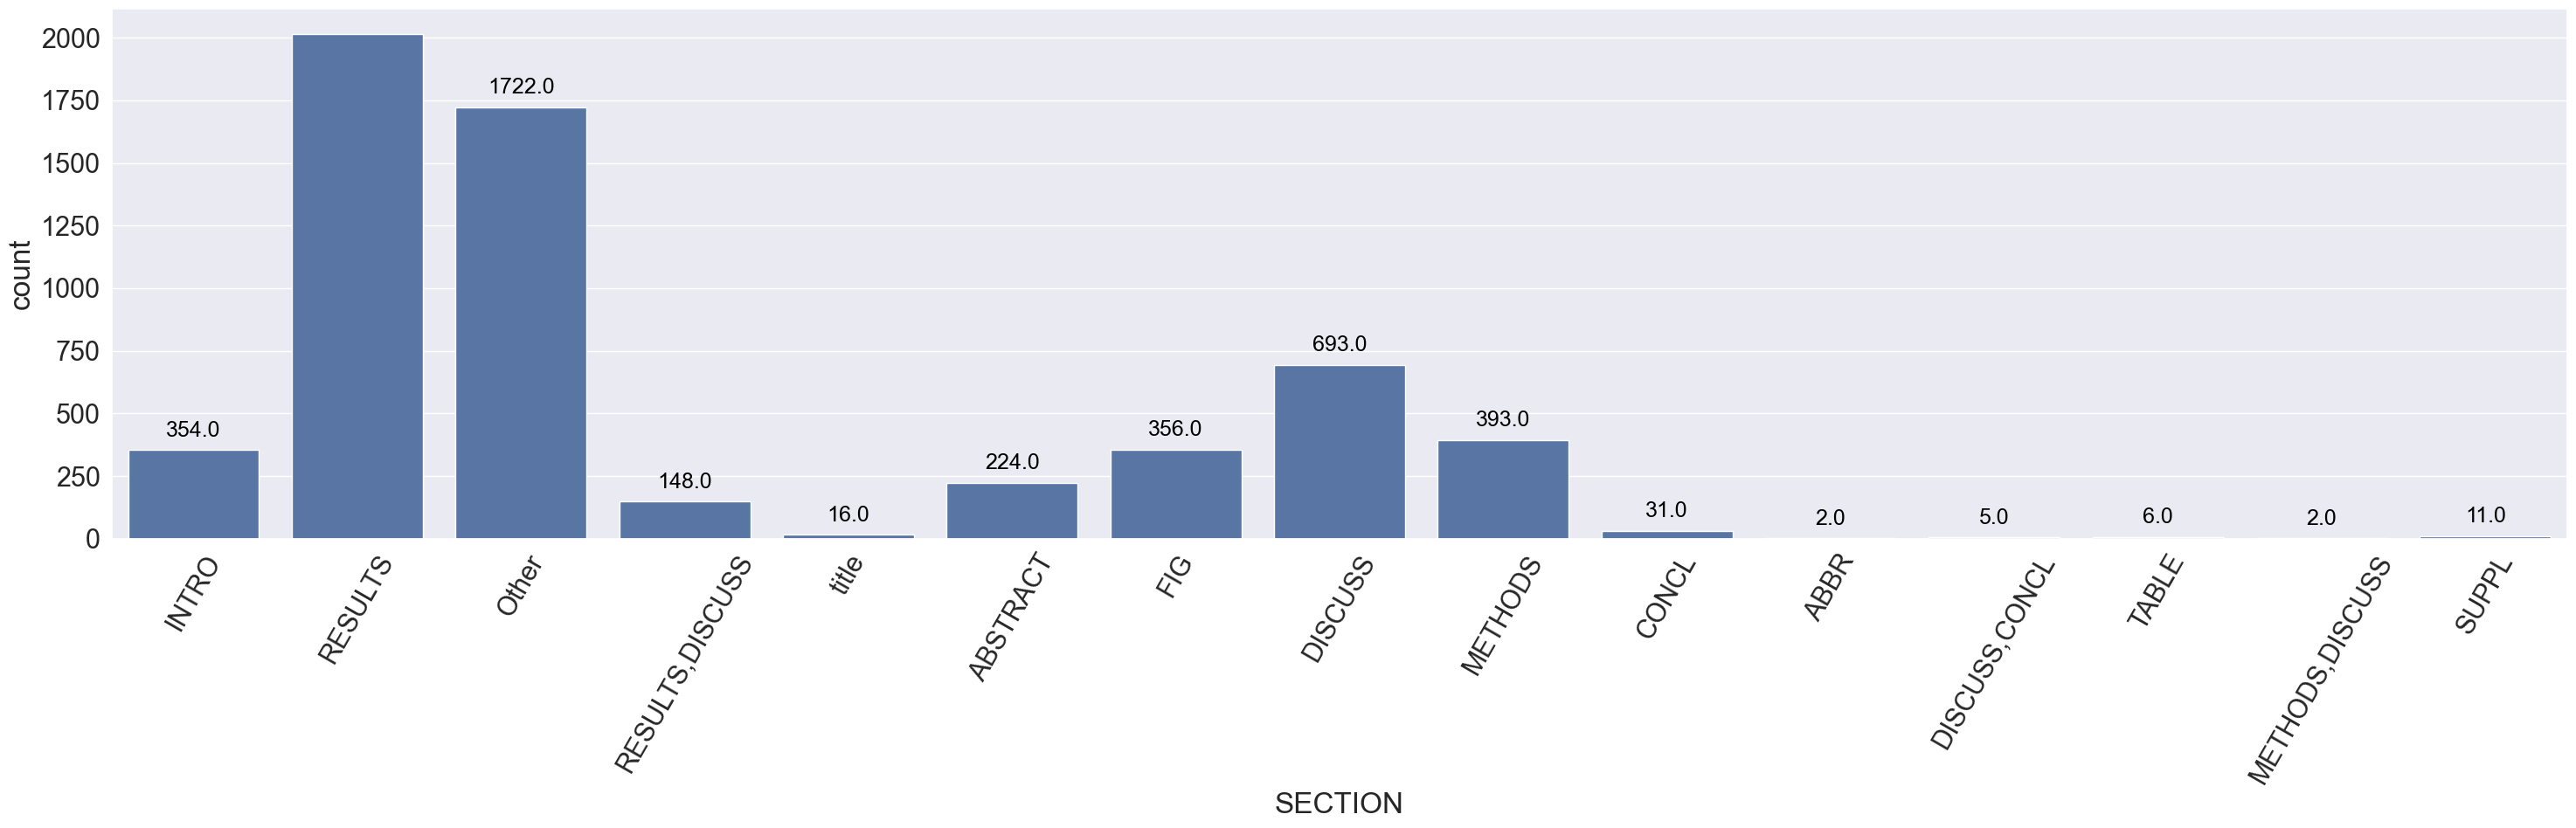

In [42]:
# Evaluated the different sections of the matching sentences
section = dataset.drop_duplicates().groupby('SECTION')['TEXT'].count().reset_index()
#display(section)


plt.figure(figsize=(30,10))
sns.set(style="darkgrid")
sns.set(font_scale = 2)

ax = sns.countplot(x="SECTION",
                   data=dataset)
ax.tick_params(axis='x', rotation=60)
for p in ax.patches:
    ax.annotate(f'\n{p.get_height()}', (p.get_x()+0.4, p.get_height()+210), ha='center', va='top', color='black', size=18)
plt.tight_layout()
plt.savefig("sections.svg")

#### Diseases reported in articles

The main search leading to mainset.csv file, was only detecting articles where both chemical probe and target were mentioned within the same sentece. Now that such link has been established, we need to look up for the thirs entity in question, the disease. 

Diseases are coming from two sources: 
* The first one (DISEASES column) is expanding the ePMC tag-based search, trying to identify disease entitites mentioned within the same sentence as the other two entities previously identified. 
* The second one (DISEASE_FOUND column), is using the ePMC annotations which identifies diseases entities within the whole article previously found having chemical probe and target.

In [43]:
# counting the diseases found
match_nd = dataset[dataset.DISEASES.isna()].drop_duplicates() #no disease
match_wd = dataset[dataset.DISEASES.notna()].drop_duplicates() #with disease 
match_df = dataset[dataset.DISEASE_FOUND.notna()].drop_duplicates() #no disease tag but annotation found

print("With disease tag: {}".format(match_wd.PMID.nunique())) #with disease tag
print("Without disease tag: {}".format( match_nd.PMID.nunique())) #without disease tag
print("Without tag but with annotation: {}".format(match_df.PMID.nunique())) #without disease tag but with disease annotation found

With disease tag: 812
Without disease tag: 958
Without tag but with annotation: 1149


##### Data rows with at least one disease tag/annotations found

In [44]:
#Counting rows with at least one disease reported in tags or annotations
probes_with_disease = dataset.dropna(subset=["DISEASES","DISEASE_FOUND"], how='all').drop_duplicates()
probes_with_disease.to_csv("data/probes_diseases_articles.csv", sep='\t', index=False)

##### The 50 most commons diseases found in probe's articles

In [45]:
#Counting the 50 most common diseases found in articles with tag-based search
diseases = match_wd.DISEASES
diseases = list(itertools.chain.from_iterable([dis.split(',') for dis in diseases]))
counter = collections.Counter(diseases)
com_dis = counter.most_common(10)

for tup in com_dis:
    print("{0} : {1}".format(tup[0],tup[1]))
    


tumor : 450
cancer : 266
Cancer : 219
chronic myeloid leukemia : 162
breast cancer : 126
ovarian cancer : 121
melanoma : 101
solid tumors : 86
non-small cell lung cancer : 85
NSCLC : 77


### Evaluating probes dataset with annotations

To construct a pilot subset that could be manually curated we needed to reduce the size of the mainset.csv file and prioritize articles. For that, we first decided to focus the search only on articles mentioning an SGC chemical probe and excluding sentences found in the section 'Other'. Then we explored articles mentioning negative controls and bioactivity measurements.

The extra annotations added to the mainset were:
* Negative control: for the identified articles we searched if in the full text it was mentioned the specific known negative control (compound name or synonym) or if a keyword related to the use of negative controls was found.
* Dosage: for the identified articles we searched if in the full text there was mentioning of any of the commonly use measurement metrics (from ChEMBL dictionary) for bioactivity values. We want to know the results of the experimental testing of the chemical probes.

#### SGC chemical probes

In [46]:
#Gets the probes in SGC subset
SGC = mainset[mainset.SET == 'SGC Probes'].PROBE.unique()

#Subsetting SGC probes without considering text found in section Others
sgcprobes = dataset[(dataset.PROBE.isin(SGC)) & (dataset.SECTION != "Other")]

print(f"Unique SGC found in mainset: {len(SGC)}")
print(f"Unique SGC found in dataset: {sgcprobes.PROBE.nunique()}")

print(f"SGC probes in mainset: {", ".join(sorted(SGC))}")
print(f"SGC probes in dataset: {", ".join(sorted(sgcprobes.PROBE.unique()))}")

print("\nSentences with SGC probes:{}\nArticles with SGC probes:{}".format(len(sgcprobes), sgcprobes.PMID.nunique()))

Unique SGC found in mainset: 56
Unique SGC found in dataset: 33
SGC probes in mainset: A-196, A-366, A-395, A-485, BAY-299, BAY-598, BAY-678, BAY-850, BAY-876, BAZ2-ICR, BI-9564, BI01383298, CA93.0, D2202-1, FM-381, GSK-J1, GSK-J4, GSK2801, GSK343, GSK4027, GSK591, GSK6853, GSK8814, I-BRD9, I-CBP112, IOX1, IOX2, JQ1, L-Moses, LLY-283, LLY-507, LP99, NI-57, NVS-CECR2-1, NVS-PAK1-1, OF-1, OICR-9429, PFI-1, PFI-3, PFI-4, SGC-AAK1-1, SGC-CBP30, SGC6870, SGC707, T-26c, T3-CLK, TH257, TP-008, TP-238, TP-472, UNC0638, UNC0642, UNC1215, UNC1999, VinSpinIn, bromosporine
SGC probes in dataset: A-196, A-366, A-395, A-485, BAY-299, BAY-598, BAY-678, BAY-850, BAY-876, BI-9564, FM-381, GSK-J1, GSK-J4, GSK2801, GSK343, GSK591, GSK6853, GSK8814, I-CBP112, JQ1, LLY-283, LLY-507, LP99, NI-57, OICR-9429, SGC707, TH257, TP-472, UNC0638, UNC0642, UNC1215, UNC1999, bromosporine

Sentences with SGC probes:1762
Articles with SGC probes:390


#### Negative control

In [47]:
#Checks articles having the negative control name, any keywords, or nothing.
conts_co = dataset.loc[dataset.CONTROL.str.startswith('C', na=False)] #control
conts_kw = dataset.loc[dataset.CONTROL.str.startswith('K', na=False)] #keyword
conts_na = dataset.loc[dataset.CONTROL.isna()] #none

#shows the unique articles for each type 
print("Control kw: {}\nControl name: {}\nNo control: {}".format(conts_kw.PMID.nunique(),conts_co.PMID.nunique(), conts_na.PMID.nunique()))

Control kw: 70
Control name: 3
No control: 1398


#### Bioactivity measurement

In [48]:
#Gets the articles mentioning units keywords related to bioactivities reported in article
dosa = dataset.loc[dataset.DOSAGE.notna()]

#shows the uique articles having bioactivity keywords
print("Articles with bioactivity kw:",dosa.PMID.nunique())

Articles with bioactivity kw: 346


### Subset for manual curation
We first tested all 3 criterion (sgc probes, negative control, and bioactivity keywords) and their possible combinations. When the 3 where used the numbers were too low and if only sgc filter applied we ended up with too many article to run a manual curation.
The reasonable approach was then to forget about the negative control and select all articles mentioning an SGC chemical probe and having some bioactivity keywords so manual curation could lead to some valuable bioactivity data.


Important to remember this subset is coming from the NLP pilot pipeline and although it is the same set of articles, it differs from the one loaded into ChEMBL 35 which is coming from MolConn extraction.

##### Selecting best subset

In [49]:
#merges and subsets the unions of all criterion
sgc_do = sgcprobes.merge(dosa, how="inner", on="PMID", suffixes=('', '_DROP')).filter(regex='^(?!.*_DROP)').drop_duplicates()
sgc_do_kw = sgc_do.merge(conts_kw, how="inner", on='PMID', suffixes=('', '_DROP')).filter(regex='^(?!.*_DROP)').drop_duplicates()
sgc_do_co = sgc_do.merge(conts_co, how="inner", on='PMID', suffixes=('', '_DROP')).filter(regex='^(?!.*_DROP)').drop_duplicates()

print("SGC",sgcprobes.PMCID.nunique()) # only SGC filter applied
print("SGC_DO",sgc_do.PMCID.nunique()) # SGC and bioactivity keywords applied
print("SGC_DO_KW",sgc_do_kw.PMCID.nunique()) # SGC, bioactivity keywords, and negative control (keywords) applied
print("SGC_DO_CO",sgc_do_co.PMCID.nunique()) # SGC, bioactivity keywords, and negative control (compound name) applied

print("\nsgc_do is selected as the best subset option")

#Cleaning diseases
sgc_do['DISEASE_FOUND'] = sgc_do.DISEASE_FOUND.str.replace('"', '').str.replace("'", '').str.replace('[', '').str.replace(']', '').apply(lambda x: "|".join(str(x).split(', ')))

print("unique probes: {}".format(sgc_do["PROBE"].nunique()))
print("unique targets: {}".format(sgc_do["GENE"].nunique()))
print("unique articles: {}".format(sgc_do["PMID"].nunique()))

SGC 389
SGC_DO 108
SGC_DO_KW 15
SGC_DO_CO 2

sgc_do is selected as the best subset option
unique probes: 22
unique targets: 24
unique articles: 108


In [50]:
#Checking how many have disease tag or annotation for the final mainset
match_nd = sgc_do[sgc_do.DISEASES.isna()].drop_duplicates() #no disease
match_wd = sgc_do[sgc_do.DISEASES.notna()].drop_duplicates() #with disease 
match_df = sgc_do[sgc_do.DISEASE_FOUND.notna()].drop_duplicates() #no disease tag but annotation found

print(f"All matches (pmid,target,probe): {len(sgc_do[['PMID','GENE', 'PROBE']].drop_duplicates())}") 
print(f"Matches with disease tag: {len(sgc_do[sgc_do.DISEASES.notna()][['PMID','GENE', 'PROBE']].drop_duplicates())}") #with disease tag
print(f"Matches without disease tag: {len(sgc_do[sgc_do.DISEASES.isna()][['PMID','GENE', 'PROBE']].drop_duplicates())}") #without disease tag
print(f"Matches without tag but with annotation: {len(sgc_do[sgc_do.DISEASE_FOUND.notna()][['PMID','GENE', 'PROBE']].drop_duplicates())}") #without disease tag but with disease annotation found

# Explanation:
# From all unique pmid, target, probe, 56 have a disease within same sentence for at least one of the sentences found within the article (it can be multiple)
#  and the remaining cases have an annotated isease

All matches (pmid,target,probe): 142
Matches with disease tag: 56
Matches without disease tag: 131
Matches without tag but with annotation: 142


In [51]:
#(external initiatives)
#Writing subset into csv for OT and ChEMBL 
sgc_do.to_csv('data/pilot_probes_sgc_do.csv', sep='\t', index=False)

#Writing subset into csv (ChEMBL)
chembl_probes = sgc_do[['PMID', 'SECTION', 'GENE', 'PROBE', 'LABEL1', 'LABEL2', 'DISEASES', 'DISEASE_FOUND', 'TEXT']].drop_duplicates()
chembl_probes.to_csv('data/pilot_probes_sgc.csv', sep='\t', index=False)

##### Cleaning subset and writing output file

Unique triples are kept for each article. The subset is giving priority to diseases found within same sentence as other entities over diseases found in full text. Also the term 'defects' is removed if other terms available.

In [52]:
# Cleaning diseases
chembl_probes_unique = chembl_probes[['PMID', 'GENE', 'PROBE', 'DISEASES', 'DISEASE_FOUND']].drop_duplicates()
condition = chembl_probes_unique['DISEASES'].notna() # Check where 'DISEASES' has a valid value (is not NaN/None)
chembl_probes_unique['DISEASE'] = np.where(condition, chembl_probes_unique['DISEASES'], chembl_probes_unique['DISEASE_FOUND'])

#Cleaning 'defects' when other disease term found
mask = chembl_probes_unique['DISEASE'].str.contains('\|', na=False) # Create a boolean mask for rows where 'DISEASE' is a string and contains '|'
chembl_probes_unique.loc[mask, 'DISEASE'] = chembl_probes_unique.loc[mask, 'DISEASE'].str.replace('|defect', '', regex=False).str.replace('defect|', '', regex=False) # On those specific rows, remove the word 'defects'

# give priority to sentences over full text
chembl_probes_unique['DISEASE_TYPE'] = np.where(condition, 'sentence', 'full_text')
chembl_probes_unique['DISEASE_TYPE'] = pd.Categorical(chembl_probes_unique['DISEASE_TYPE'], categories=['sentence', 'full_text'], ordered=True)

# Sort the DataFrame. For each group of duplicates, the 'sentence' row will now be first.
chembl_probes_unique = chembl_probes_unique.sort_values('DISEASE_TYPE')

# Drop duplicates based on the key columns, keeping the first entry.
final_df = chembl_probes_unique.drop_duplicates(subset=['PMID', 'GENE', 'PROBE'], keep='first')
chembl_probes_unique = chembl_probes_unique.drop(columns=['DISEASES', 'DISEASE_FOUND'])

# Write into file
chembl_probes_unique.to_csv('data/pilot_probes_triples.csv', sep='\t', index=False)

#print numbers
print("unique probes: {}".format(chembl_probes_unique["PROBE"].nunique()))
print("unique targets: {}".format(chembl_probes_unique["GENE"].nunique()))
print("unique articles: {}".format(chembl_probes_unique["PMID"].nunique()))


unique probes: 22
unique targets: 24
unique articles: 108


<>:7: SyntaxWarning: invalid escape sequence '\|'
<>:7: SyntaxWarning: invalid escape sequence '\|'
/var/folders/1h/mvhd393j60q_lnyl0qsdgkgw0000gp/T/ipykernel_3695/751116068.py:7: SyntaxWarning: invalid escape sequence '\|'
  mask = chembl_probes_unique['DISEASE'].str.contains('\|', na=False) # Create a boolean mask for rows where 'DISEASE' is a string and contains '|'


In [53]:
display(sgc_do.head(1))

,PMID,SECTION,TAR,GENE,COMP,PROBE,CONTR,LABEL1,LABEL2,START1,END1,START2,END2,TEXT,DISEASES,DISEASE_FOUND,DOSAGE,CONTROL,PMCID,ASSAY
0,22046134,FIG,O60885,BRD4,29336,JQ1,(-)-JQ1,BRD4,JQ1,115,119,190,193,"(A) Transcription of the Cp-initiated transcripts EBNA 2 and EBNA 1, but not the LMP1 transcript is inhibited when Brd4 binding to chromatin is blocked in the presence of the Brd4 inhibitor JQ1.",NaN,tumour|Burkitts lymphoma,"Strikingly, treatment with 50 nM JQ1 for 48 hrs reduced levels of Cp-initiated EBNA 2 and EBNA 1 transcripts by 74% and 65% respectively, but had no effect on LMP1 transcript levels (Figure 9A).|Mutu III cells were treated with 50 nM JQ1 or DMSO (control) for 48 hrs and transcript levels determined using specific Q-PCR primers and actin as an endogenous control.|ChIP using anti-Brd4 (B), anti-CDK9 (C) and anti-cyclin T1 antibodies (D) in Mutu III cells in the absence (black bars) or presence of 50 nM JQ1 for 48 hrs (open bars).",NaN,PMC3203192,NaN


#### Section by entities found

array(['FIG', 'DISCUSS', 'ABSTRACT', 'RESULTS', 'METHODS', 'title',
       'INTRO', 'RESULTS,DISCUSS', 'CONCL', 'DISCUSS,CONCL', 'SUPPL'],
      dtype=object)

,SECTION,TEXT
0,ABSTRACT,52
1,CONCL,6
2,DISCUSS,100
3,FIG,51
4,INTRO,43
5,METHODS,39
6,RESULTS,361
7,SUPPL,2
8,TITLE,4


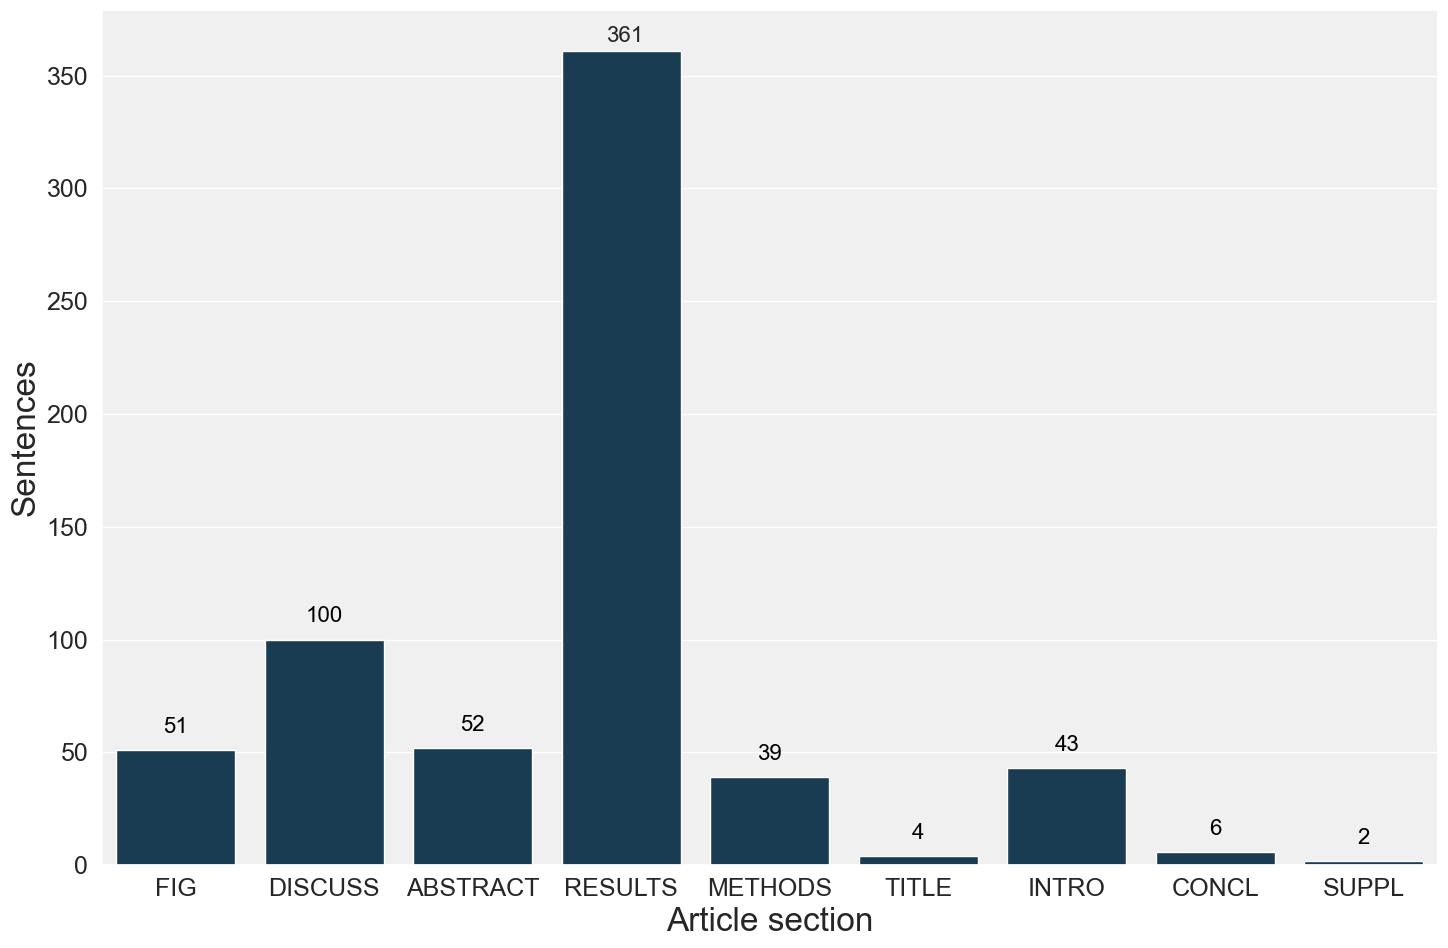

In [54]:
#clean sections titles
display(sgc_do.SECTION.unique())
sgc_do['SECTION'] = sgc_do['SECTION'].replace('DISCUSS,CONCL', 'DISCUSS').replace('title', 'TITLE').replace('RESULTS,DISCUSS', 'RESULTS')

# Evaluated the different sections of the matching sentences
section = sgc_do.drop_duplicates().groupby('SECTION')['TEXT'].count().reset_index()
display(section)

# Set the background color of the plot
fig, ax = plt.subplots(figsize=(15, 10))  # Assuming you're creating the figure and axes here
ax.set_facecolor('#f0f0f0')  # Set the background color


ax = sns.countplot(x="SECTION", data=sgc_do, color="#103e5b")
ax.tick_params(axis='x')

for p in ax.patches:
    # Adjust vertical offset and potentially reduce font size if needed
    ax.annotate(f'\n{int(p.get_height())}', (p.get_x()+0.4, p.get_height()+25), 
                ha='center', va='top', color='black', size=16) 

ax.annotate('361', (2.9,365), size=16)

# Set the new y-axis label
ax.set_ylabel("Sentences", fontsize=24)
ax.set_xlabel("Article section", fontsize=24)
plt.tick_params(axis='both', which='major', labelsize=18)

plt.tight_layout()
plt.savefig("figs/pilot_sections_subset.png", dpi=300)

#### Unique pairs and articles

It is possible to have multiple articles reporting the use of a probe-target pair. Having the count of articles by pair offers an insight on the most commonly used probes or the highly well-studied targets. On the other hand, the numbers suggest a clear inbalance in the data that may be worth consider for future applications in machine learning.

In [55]:
#Extract the counts of unique pairs and pivot the data
pair_matches = chembl_probes.drop_duplicates().groupby(['PROBE','GENE'])['PMID'].nunique().reset_index().sort_values('PMID')
pd.set_option('display.max_rows', None)

#gets the date of release for probes
probes_scg_dates = 'data/probes_date_SGC.csv'
dates = pd.read_csv(probes_scg_dates, sep="\t").set_index('PROBE')['DATE'].to_dict()

pair_matches['DATE'] = pair_matches.PROBE.map(dates).fillna('None')
pair_matches[['DATE_MONTH', 'DATE_YEAR']] = pair_matches['DATE'].str.split('-', n=1, expand=True)

pair_matches.drop(columns=['DATE'], inplace=True)
labels = pair_matches.sort_values(by="DATE_YEAR")['PROBE'].unique()
display(pair_matches)
    
result = pair_matches.pivot(index='GENE', columns='PROBE', values='PMID')

,PROBE,GENE,PMID,DATE_MONTH,DATE_YEAR
0,A-366,EHMT1,1,Jun,13
5,BAY-850,ATAD2,1,Jan,17
7,BI-9564,BRD9,1,Apr,15
11,GSK2801,BAZ2A,1,Dec,14
12,GSK2801,BAZ2B,1,Dec,14
15,GSK8814,ATAD2,1,Jan,17
23,NI-57,BRD1,1,Dec,14
19,JQ1,BRDT,1,Jun,08
20,LLY-283,PRMT5,1,Jul,16
22,LP99,BRD9,1,Dec,14


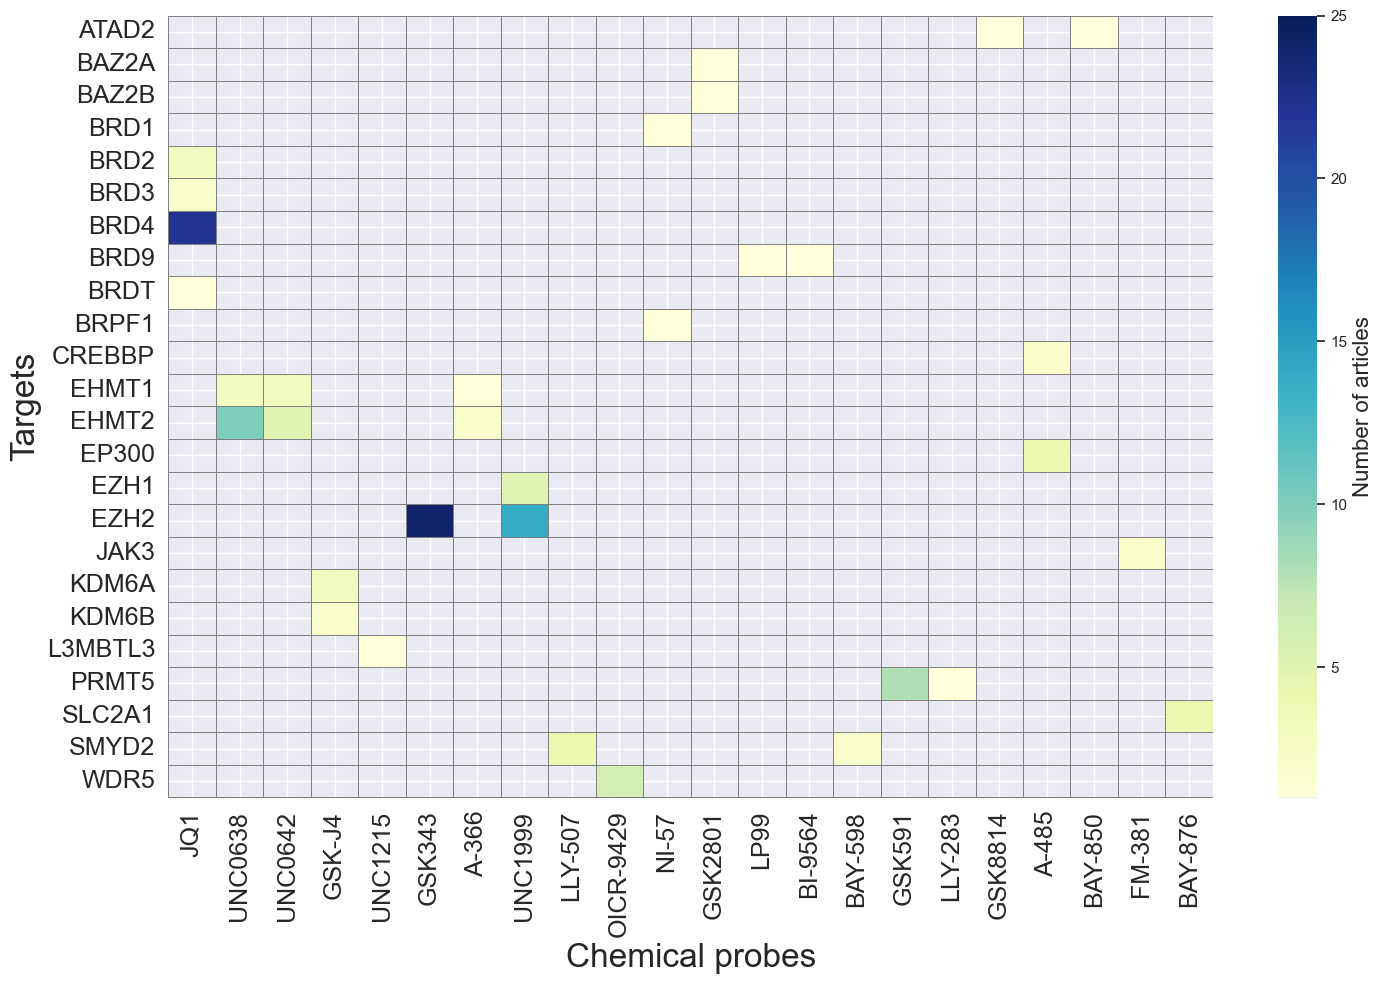

In [56]:
#Gets the distribution of the pair
plt.figure(figsize=(15,10))
sns.set(style="darkgrid")
# Define the blue gradient colormap
cmap = sns.color_palette("blend:#3489CA,#103e5b", as_cmap=True)
ax = sns.heatmap(result[labels], cmap="YlGnBu", vmax=25, linewidths=0.5, linecolor='gray', xticklabels=True, yticklabels=True, cbar_kws={'label': 'Number of articles'})
ax.tick_params(axis='x', rotation=90)

#plt.show()
# Increase the size of the colorbar label
cbar = ax.collections[0].colorbar
cbar.ax.set_ylabel(cbar.ax.get_ylabel(), fontsize=16)

# Set the new y-axis label
ax.set_ylabel("Targets", fontsize=24)
ax.set_xlabel("Chemical probes", fontsize=24)
plt.tick_params(axis='both', which='major', labelsize=18)

plt.tight_layout()
plt.savefig("figs/heatmap.png", dpi=300)



#### Chemical probes characterization

In [57]:
#From unique probes how many are drugs?
sgc_do['INCHI'] = sgc_do['PROBE'].map(probes_inchi)
sgc_do['MAX_PHASE'] = sgc_do['INCHI'].apply(lambda x: chembl.get_max_phase(x)[0]) 
sgc_do['CHEMBLID'] = sgc_do['INCHI'].apply(lambda x: chembl.get_chemblid(x)[0]) 
sgc_do['PROBE_DATE'] = sgc_do['PROBE'].map(dates)
sgc_do['PROBE_DATE'] = pd.to_datetime(sgc_do['PROBE_DATE'], format='%b-%y')
display(sgc_do[['PROBE', 'INCHI','CHEMBLID', 'MAX_PHASE', 'PROBE_DATE']].drop_duplicates().sort_values(by='PROBE_DATE').reset_index(drop=True))

,PROBE,INCHI,CHEMBLID,MAX_PHASE,PROBE_DATE
0,JQ1,DNVXATUJJDPFDM-KRWDZBQOSA-N,CHEMBL1957266,None,2008-06-01
1,UNC0638,QOECJCJVIMVJGX-UHFFFAOYSA-N,CHEMBL1231795,None,2008-06-01
2,GSK-J4,WBKCKEHGXNWYMO-UHFFFAOYSA-N,CHEMBL3183531,None,2012-07-01
3,UNC1215,PQOOIERVZAXHBP-UHFFFAOYSA-N,CHEMBL2426364,None,2012-08-01
4,GSK343,ULNXAWLQFZMIHX-UHFFFAOYSA-N,CHEMBL2204995,None,2012-08-01
5,UNC0642,RNAMYOYQYRYFQY-UHFFFAOYSA-N,CHEMBL2441082,None,2012-08-01
6,UNC1999,DPJNKUOXBZSZAI-UHFFFAOYSA-N,CHEMBL3414619,None,2013-05-01
7,A-366,BKCDJTRMYWSXMC-UHFFFAOYSA-N,CHEMBL3109630,None,2013-06-01
8,LLY-507,PNYRDVBFYVDJJI-UHFFFAOYSA-N,CHEMBL3414623,None,2013-11-01
9,OICR-9429,DJOVLOYCGXNVPI-UHFFFAOYSA-N,CHEMBL3798846,None,2014-05-01


In [58]:
# Check if articles already in ChEMBL
#from databases import ChemblDB
#chembl = ChemblDB()
#pubmeds = [pubmed[0] for pubmed in chembl.get_all_docs()] #obtains all pubmeds in chembl
#check = [pub for pub in chembl_probes.PMID.tolist() if pub in pubmeds ] # checks if pubmeds in dataset already in chembl
#check

In [59]:
##Constructing ChEMBL dataset

#chembl_data = pd.read_csv('../data/probes/probes_articles_SGC.csv', sep='\t')
#sgc_data = sgc_do[['PMID', 'SECTION', 'GENE', 'PROBE', 'CONTR', 'LABEL1', 'LABEL2', 'TEXT', 'DISEASES', 'DISEASE_FOUND']].drop_duplicates()

#print(len(sgc_data))
#sgc_data.to_csv('../data/probes/probes_articles_SGC(diseases).csv', sep='\t', index=False)

#### Diseases in subset

In [66]:
print('All articles')
print(sgc_do.PMID.nunique()) ##
match_nd = sgc_do[sgc_do.DISEASES.isna()].drop_duplicates() #no disease
match_wd = sgc_do[sgc_do.DISEASES.notna()].drop_duplicates() #with disease 
match_df = sgc_do[sgc_do.DISEASE_FOUND.notna()].drop_duplicates() #no disease tag but annotation found

#removing non found
check_dis = sgc_do.dropna(subset=['DISEASES'])
#Cleaning diseases
check_dis['DISEASES'] = check_dis.DISEASES.astype(str).replace('NE,prostate cancer,CRPC', 'NE').replace('cancer,HCC', 'HCC').replace('MCC,tumors', 'MCC').replace('leukemia,AML', 'AML').replace('acute myeloid leukemia,AML', 'AML').replace('tumor,AML','AML').replace('ovarian cancer,cancer','ovarian cancer').replace('cancer,ovarian cancer,tumor', 'ovarian cancer').replace('tumor,ovarian cancer', 'ovarian cancer').replace('leukemia,pancreatic cancer,neuroblastoma','pancreatic cancer').replace('cancer,tumour','cancer').replace('lymphoma,cancer,myeloma','myeloma').replace('HCC,lymphoma,tumour','HCC').replace('NASH,liver steatosis', 'NASH').replace('tumor,MB', 'MB')

print('Articles witth sentence cooccurrence of diseases')
print(check_dis.PMID.nunique()) 
display(match_wd.DISEASES.nunique())
display(match_df.DISEASE_FOUND.nunique())


dis_coocc = check_dis[['PMID','PROBE','GENE','DISEASES']].drop_duplicates()
print('unique pmid, probe, target, disease')
print(len(dis_coocc))
#display(dis_coocc.head(2).sort_values(by='GENE'))


All articles
108
Articles witth sentence cooccurrence of diseases
45


/var/folders/1h/mvhd393j60q_lnyl0qsdgkgw0000gp/T/ipykernel_3695/993066629.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  check_dis['DISEASES'] = check_dis.DISEASES.astype(str).replace('NE,prostate cancer,CRPC', 'NE').replace('cancer,HCC', 'HCC').replace('MCC,tumors', 'MCC').replace('leukemia,AML', 'AML').replace('acute myeloid leukemia,AML', 'AML').replace('tumor,AML','AML').replace('ovarian cancer,cancer','ovarian cancer').replace('cancer,ovarian cancer,tumor', 'ovarian cancer').replace('tumor,ovarian cancer', 'ovarian cancer').replace('leukemia,pancreatic cancer,neuroblastoma','pancreatic cancer').replace('cancer,tumour','cancer').replace('lymphoma,cancer,myeloma','myeloma').replace('HCC,lymphoma,tumour','HCC').replace('NASH,liver steatos

51

106

unique pmid, probe, target, disease
79


#### Grounding to OT ids

In [61]:
#Mapping to OT ids
grounding = pd.read_csv('/Users/adasme/Documents/codes/data/probes/probes_otevidence/10_24/epmc_ner_results_subset_sent.tsv', sep='\t') #Files contains entitites with mapping to OT ontologies
otdict = dict(zip(grounding['label'], grounding['label_id']))

#Manually correcting some diseases
#display(dis_coocc[['DISEASES','TEXT']])
dis_coocc.DISEASES = dis_coocc.DISEASES.str.replace('tumors', 'tumor').replace('NE', 'prostate cancer').replace('UPEC infection', 'infection').replace('HGSOC', 'High-grade serous ovarian cancer').replace('lung cancercell','lung cancer').replace('EOAD',"Alzheimer's disease").replace('ovarian cancer', 'epithelial ovarian cancer').replace('melanoma tumor', 'melanoma').replace('MB','medulloblastoma').replace('OCCC', 'ovarian clear cell adenocarcinoma')

#Manually correcting missing gene to ensembl
otdict['SLC2A1'] = 'ENSG00000117394'

display(grounding.sentence.nunique())

19517

In [62]:
#mapping to OT ids
chembliddict = dict(zip(sgc_do['PROBE'], sgc_do['CHEMBLID'])) #chemblid was added before for other purposes
dis_coocc['GENE_ID'] = dis_coocc['GENE'].map(lambda gene: otdict.get(gene, np.nan))
dis_coocc['PROBE_ID'] = dis_coocc['PROBE'].map(chembliddict)
dis_coocc['DISEASE_ID'] = dis_coocc['DISEASES'].map(lambda disease: otmap.find_term(disease)[0][1] if len(otmap.find_term(disease)) > 0 else None)

In [63]:
#cases without disease map
display(dis_coocc[dis_coocc.DISEASE_ID.isna()])

,PMID,PROBE,GENE,DISEASES,GENE_ID,PROBE_ID,DISEASE_ID
6436,29619268,JQ1,BRD4,OCs,ENSG00000141867,CHEMBL1957266,None
6744,30026560,GSK591,PRMT5,OL,ENSG00000100462,CHEMBL4542380,None


In [64]:
#Only SGC probes, with articles mentioning 3 entities within the same sentence. 
# Grouped by probe-gene pair, aggregated diseases and count of articles.
#Show only cases with ids
data_ids = dis_coocc.dropna(subset='DISEASE_ID')[['PMID','PROBE','GENE','DISEASES']]
from collections import Counter

grouped_df = data_ids.groupby(['PROBE', 'GENE']).agg({
    'DISEASES': lambda x: ', '.join([f'{item}[{count}]' for item, count in Counter(x).items()]),
    'PMID': 'count'
}).sort_values(by=['PMID']).reset_index()

# Rename aggregated columns
grouped_df.columns = ['PROBE', 'GENE', 'ALL_DISEASES', 'ARTICLES']

display(grouped_df)

,PROBE,GENE,ALL_DISEASES,ARTICLES
0,A-366,EHMT1,AML[1],1
1,A-485,CREBBP,tumor[1],1
2,A-485,EP300,tumor[1],1
3,BAY-598,SMYD2,NSCLC[1],1
4,GSK-J4,KDM6A,infection[1],1
5,BI-9564,BRD9,tumor[1],1
6,UNC0638,EHMT1,breast cancer[1],1
7,LLY-283,PRMT5,GBM[1],1
8,UNC1215,L3MBTL3,malignant brain tumor[1],1
9,BAY-876,SLC2A1,"cancer[1], epithelial ovarian cancer[1]",2


FileNotFoundError: [Errno 2] No such file or directory: '../figs/gene_disease_heatmap.png'

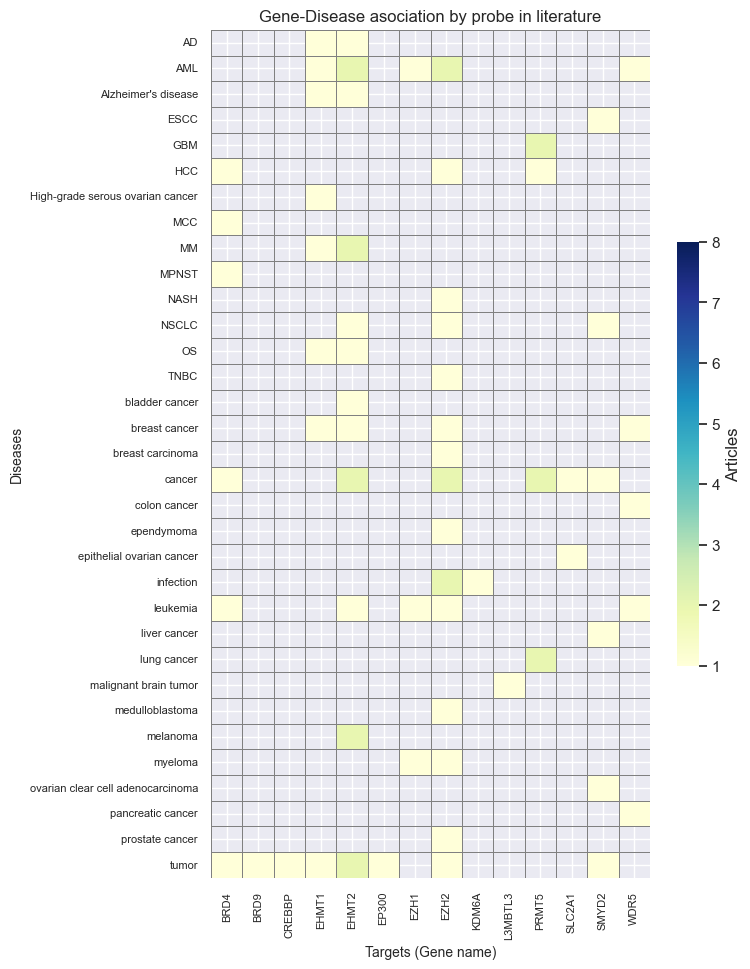

In [65]:

gr = data_ids.groupby(['GENE', 'DISEASES']).agg({'PMID': 'count'}).sort_values(by=['PMID']).reset_index()
pivot_table = gr.pivot_table(index="DISEASES", columns="GENE", values="PMID")

plt.figure(figsize=(8,10))
sns.set(style="darkgrid")
# Define the blue gradient colormap
cmap = sns.color_palette("blend:#3489CA,#103e5b", as_cmap=True)


ax = sns.heatmap(
    pivot_table,
    annot=False,
    cmap="YlGnBu",
    vmax=8,
    linewidths=0.5,
    linecolor='gray',
    xticklabels=True, yticklabels=True,
    fmt=".1f",
    cbar_kws={"label": "Articles", "shrink": 0.5}
)

# Set the title of the heatmap.
ax.set_title("Gene-Disease asociation by probe in literature")
ax.set_xlabel("Targets (Gene name)", fontsize=10)
ax.set_ylabel("Diseases", fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation = 90, fontsize = 8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 8)
sns.set(font_scale=1.4)


# Display the heatmap.
plt.tight_layout()


plt.savefig("../figs/gene_disease_heatmap.png", dpi=400)
plt.show()

In [ ]:
#NUMBERS
# 
print('counting entities by term')
print(data_ids.PMID.nunique())
display(data_ids.DISEASES.nunique())
display(grouped_df.PROBE.nunique())
display(grouped_df.GENE.nunique())

print('counting entities by id')
display(dis_coocc.PMID.nunique())
display(dis_coocc.DISEASE_ID.nunique())
display(dis_coocc.PROBE_ID.nunique())
display(dis_coocc.GENE_ID.nunique())


In [ ]:
fig = go.Figure(data=[go.Table(
    header=dict(values=list(grouped_df.columns),
                fill_color='#103e5b',
                font=dict(color='white'),
                align='left'),
    cells=dict(values=[grouped_df.PROBE,
                       grouped_df.GENE, 
                       grouped_df.ALL_DISEASES, 
                       grouped_df.ARTICLES],
                fill_color='#f0f0f0',
                align='left'),
                columnwidth=[1.2, 1.2, 3.5,1.1])
])

fig.update_layout(width=660, height=1500, paper_bgcolor='white') # Set the plot area background color to light gray)
fig.write_image("../figs/table.png", scale=3)  # Set scale to 3 for 300 DPI

#### Checking coococurrences from OT EPMC data

In [ ]:
display(dis_coocc.PMID.nunique())
display(data_ids.PMID.nunique())

## check how many articles have data in OT data
display(grounding.pmid.nunique())
## In those  articles, how many probes were found in each?
display(len(dis_coocc.TEXT.unique()))
display(len(grounding.sentence.unique()))
display(grounding.head(4))

In [ ]:
import pandas as pd
from matplotlib_venn import venn2
import matplotlib.pyplot as plt


# Convert sentences to sets for easy comparison
set1 = set(dis_coocc['TEXT'])
set2 = set(grounding['sentence'])

print(len(set1),len(set2))

# Find common and different sentences
common_sentences = set1.intersection(set2)
df1_unique_sentences = set1.difference(set2)
df2_unique_sentences = set2.difference(set1)

# Print results
print(f"Number of common sentences: {len(common_sentences)}")
print(f"Common sentences: {common_sentences}")
print(f"Sentences unique to df1: {df1_unique_sentences}")
print(f"Sentences unique to df2: {df2_unique_sentences}")

# Generate Venn Diagram
v = venn2(subsets=(len(df1_unique_sentences), len(df2_unique_sentences), len(common_sentences)), 
      set_labels=('gold standard', 'OT annotations'))
plt.title("Venn Diagram of Sentence Overlap")

# Hide the values
for text in v.subset_labels:
    text.set_visible(False)

plt.show()

In [ ]:
## Transforming OT data intro triples cooccurrencies for labels
rerun=False
if rerun: #doesn't calculate all again
  def extract_triplets(group):
      """
      Extracts unique triplets of CD, GP, and DS entities from a group,
      filling missing entities with None.
      """
      cd = group[group['entity_type'] == 'CD']['label'].unique()
      gp = group[group['entity_type'] == 'GP']['label'].unique()
      ds = group[group['entity_type'] == 'DS']['label'].unique()

      # If any entity type is missing, replace with [None]
      if len(cd) == 0:
        cd = [None]
      if len(gp) == 0:
        gp = [None]
      if len(ds) == 0:
        ds = [None]

      # Create a list of dictionaries with all possible combinations
      triplets = [{'CD': cd_val, 'GP': gp_val, 'DS': ds_val}
                  for cd_val in cd for gp_val in gp for ds_val in ds]
      return pd.DataFrame(triplets)

  # Group by 'pmid' and 'sentence'
  grouped = grounding.groupby(['pmid', 'sentence'])

  # Apply the extract_triplets function to each group
  result = grouped.apply(extract_triplets).reset_index()

  # Check the number of index levels and drop accordingly
  if len(result.index.names) > 1:
      result = result.droplevel(level=2)
  result.to_csv("../probes_OT/gs/ot_gs_triples_all.csv", sep='\t', index=False)

else:
   result = pd.read_csv("../probes_OT/gs/ot_gs_triples_all.csv", sep='\t')
display(result.head(1))

In [ ]:
## Transforming OT data intro triples cooccurrencies for label ids
rerun=False
if rerun: #doesn't calculate all again
  def extract_triplets(group):
      """
      Extracts unique triplets of CD, GP, and DS entities from a group,
      filling missing entities with None.
      """
      cd = group[group['entity_type'] == 'CD']['label_id'].unique()
      gp = group[group['entity_type'] == 'GP']['label_id'].unique()
      ds = group[group['entity_type'] == 'DS']['label_id'].unique()

      # If any entity type is missing, replace with [None]
      if len(cd) == 0:
        cd = [None]
      if len(gp) == 0:
        gp = [None]
      if len(ds) == 0:
        ds = [None]

      # Create a list of dictionaries with all possible combinations
      triplets = [{'CD': cd_val, 'GP': gp_val, 'DS': ds_val}
                  for cd_val in cd for gp_val in gp for ds_val in ds]
      return pd.DataFrame(triplets)

  # Group by 'pmid' and 'sentence'
  grouped = grounding.groupby(['pmid', 'sentence'])

  # Apply the extract_triplets function to each group
  result_id = grouped.apply(extract_triplets).reset_index()

  # Check the number of index levels and drop accordingly
  if len(result_id.index.names) > 1:
      result_id = result_id.droplevel(level=2)
  result_id.to_csv("../probes_OT/gs/ot_gs_triples_all_id.csv", sep='\t', index=False)

else:
   result_id = pd.read_csv("../probes_OT/gs/ot_gs_triples_all_id.csv", sep='\t')
display(result.head(1))

In [ ]:

otdata_triplets = result_id.dropna()
print(len(otdata_triplets), otdata_triplets.pmid.nunique())
display(otdata_triplets.head(1))
nlp_triplets = dis_coocc.dropna(subset='DISEASE_ID')[['PMID','PROBE_ID','GENE_ID','DISEASE_ID']].rename(columns={'PROBE_ID':'CD','GENE_ID':'GP','DISEASE_ID':'DS'})
(display(nlp_triplets.head(1)))

nlp_triplets['DS'] = nlp_triplets.DS.str.replace(':','_')
merged_df = pd.merge(otdata_triplets, nlp_triplets, on=['CD','GP'], how='inner')

display(len(nlp_triplets))
display(len(otdata_triplets))
display(len(merged_df))

display(merged_df.head())